# Phase 3: Market Analysis for Stakeholders

**Course**: Data Science and AI - Sharif University  
**Team**: Bahman Farhadian, Mahdi Samadi Azar  
**Dataset**: Divar Real Estate Advertisements (1M records)

---

## Objective

Deliver actionable insights for buyers and sellers in the Iranian real estate market.

> **Instructor's guidance**: "Don't go for very technical format or very high-level complex models. This question doesn't have that capacity. The audience will reject it if you try to show them that way."

> "You don't need extensive market study. You need MORE THINKING."

## What This Notebook Covers

1. **Data Loading & Preparation** - Load cleaned data from Phase 2
2. **Market Overview** - Overall market size and city distribution
3. **Buyer Analysis** - Where to buy, price factors, amenity impact
4. **Seller Analysis** - Pricing guidance, competition, timing
5. **Rental Market Brief** - Overview for renters and landlords
6. **Key Recommendations** - Actionable insights for stakeholders

## Target Stakeholders

**Buyers**: Individuals seeking to purchase residential property who need to understand fair pricing, valuable locations, and what features affect price.

**Sellers**: Property owners looking to list their property who need guidance on competitive pricing and understanding what adds value to their listing.

---

## 1. Setup and Library Imports

We use the same libraries and configuration as previous phases for consistency.

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Persian text display fix for matplotlib
import arabic_reshaper
from bidi.algorithm import get_display

def fix_persian(text):
    """Reshape Persian/Arabic text for correct display in matplotlib.
    RTL languages need special handling to display correctly in plots."""
    if pd.isna(text):
        return 'Unknown/NULL'
    reshaped = arabic_reshaper.reshape(str(text))
    return get_display(reshaped)

# Display settings for better output readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
sns.set_style('whitegrid')

# Color palette (consistent with Phase 2)
COLORS = {
    'primary': '#2ecc71',
    'secondary': '#3498db',
    'accent': '#e74c3c',
    'neutral': '#95a5a6',
    'sell': '#27ae60',
    'rent': '#3498db'
}

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Project Structure and Path Configuration

In [96]:
# Define project paths
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES_PATH = PROJECT_ROOT / 'notebooks' / 'outputs' / 'figures'

# Create output directories if they don't exist
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data path: {DATA_PROCESSED}")
print(f"Figures path: {FIGURES_PATH}")

Project root: /home/bahman/b/repositories/pydsai_divar_real_estate_analysis_hossein_hamzehi_mahdi_samdi_azar
Processed data path: /home/bahman/b/repositories/pydsai_divar_real_estate_analysis_hossein_hamzehi_mahdi_samdi_azar/data/processed
Figures path: /home/bahman/b/repositories/pydsai_divar_real_estate_analysis_hossein_hamzehi_mahdi_samdi_azar/notebooks/outputs/figures


## 3. Load Data from Phase 2

We load the enhanced dataset that includes the `price_per_sqm` feature created in Phase 2.

In [97]:
# Load the enhanced dataset from Phase 2
DATA_FILE = DATA_PROCESSED / 'cleaned_data_with_features.csv'

print(f"Loading data from: {DATA_FILE}")
df = pd.read_csv(DATA_FILE, low_memory=False)

print(f"\nDataset loaded: {len(df):,} rows, {df.shape[1]} columns")
print(f"\nListings by type:")
for lt, count in df['listing_type'].value_counts().items():
    print(f"  {lt}: {count:,} ({count/len(df)*100:.1f}%)")

Loading data from: /home/bahman/b/repositories/pydsai_divar_real_estate_analysis_hossein_hamzehi_mahdi_samdi_azar/data/processed/cleaned_data_with_features.csv

Dataset loaded: 1,000,000 rows, 71 columns

Listings by type:
  sell: 597,569 (59.8%)
  rent: 383,028 (38.3%)
  other: 19,403 (1.9%)


In [98]:
# Ensure numeric types
df['price_value'] = pd.to_numeric(df['price_value'], errors='coerce')
df['building_size'] = pd.to_numeric(df['building_size'], errors='coerce')
df['price_per_sqm'] = pd.to_numeric(df['price_per_sqm'], errors='coerce')
df['rent_value'] = pd.to_numeric(df['rent_value'], errors='coerce')
df['credit_value'] = pd.to_numeric(df['credit_value'], errors='coerce')

# Create clean datasets for analysis
# For sale: valid price per sqm, reasonable range (5M - 500M Tomans/sqm)
df_sell = df[
    (df['listing_type'] == 'sell') & 
    (df['price_per_sqm'].notna()) &
    (df['price_per_sqm'] > 5_000_000) &
    (df['price_per_sqm'] < 500_000_000)
].copy()

# For rent: valid rent or credit values
df_rent = df[
    (df['listing_type'] == 'rent') &
    ((df['rent_value'].notna()) | (df['credit_value'].notna()))
].copy()

print(f"Sale listings (clean): {len(df_sell):,}")
print(f"Rental listings: {len(df_rent):,}")

Sale listings (clean): 474,693
Rental listings: 352,217


---

## 4. Market Overview

Before providing specific advice, we need to understand the overall market structure.

### 4.1 Identify Major Cities

We define major cities as those with at least 5,000 listings to ensure statistical reliability.

In [99]:
# Identify major cities (more than 5,000 listings)
city_counts = df['city_slug'].value_counts()
major_cities = city_counts[city_counts >= 5000].index.tolist()

print(f"Major Cities: {len(major_cities)} cities with 5,000+ listings")
print("=" * 60)
print(f"{'Rank':<6} {'City':<25} {'Listings':>12} {'Share':>10}")
print("-" * 60)

for i, city in enumerate(major_cities[:15], 1):
    count = city_counts[city]
    share = count / len(df) * 100
    city_name = city.replace('-', ' ').title()
    print(f"{i:<6} {city_name:<25} {count:>12,} {share:>9.1f}%")

Major Cities: 35 cities with 5,000+ listings
Rank   City                          Listings      Share
------------------------------------------------------------
1      Tehran                         190,904      19.1%
2      Mashhad                         69,032       6.9%
3      Karaj                           49,367       4.9%
4      Shiraz                          37,141       3.7%
5      Isfahan                         36,953       3.7%
6      Tabriz                          27,655       2.8%
7      Andisheh New Town               20,847       2.1%
8      Ahvaz                           19,590       2.0%
9      Qom                             17,109       1.7%
10     Kermanshah                      17,048       1.7%
11     Rasht                           16,833       1.7%
12     Urmia                           13,466       1.3%
13     Bandar Abbas                    11,555       1.2%
14     Pardis City                     11,396       1.1%
15     Kerman                          

### 4.2 Market Distribution Visualization

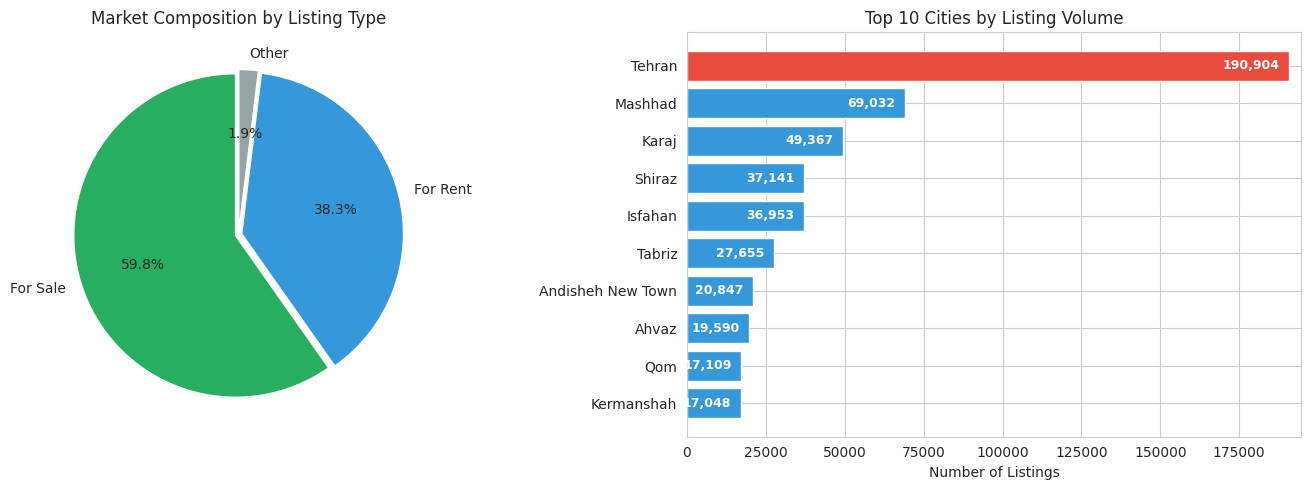


Key Finding: Tehran dominates with 190,904 listings (19.1% of market)


In [100]:
# Market overview visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Listing type breakdown (pie chart)
type_counts = df['listing_type'].value_counts()
colors_pie = [COLORS['sell'], COLORS['rent'], COLORS['neutral']]
wedges, texts, autotexts = axes[0].pie(
    type_counts.values, 
    labels=['For Sale', 'For Rent', 'Other'], 
    autopct='%1.1f%%', 
    colors=colors_pie, 
    startangle=90,
    explode=[0.02, 0.02, 0.02]
)
axes[0].set_title('Market Composition by Listing Type')

# Right: Top 10 cities by listings (horizontal bar)
top_cities = city_counts.head(10)
city_names = [c.replace('-', ' ').title() for c in top_cities.index]
colors_bar = [COLORS['accent'] if c == 'tehran' else COLORS['secondary'] for c in top_cities.index]

y_pos = range(len(top_cities))
axes[1].barh(y_pos, top_cities.values, color=colors_bar)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(city_names)
axes[1].invert_yaxis()
axes[1].set_xlabel('Number of Listings')
axes[1].set_title('Top 10 Cities by Listing Volume')

# Add value labels inside bars
for i, val in enumerate(top_cities.values):
    axes[1].text(val - 3000, i, f'{val:,}', va='center', ha='right', fontsize=9, color='white', fontweight='bold')

# Add padding to x-axis
axes[1].set_xlim(0, max(top_cities.values) * 1.02)

plt.tight_layout()
plt.savefig(FIGURES_PATH / '03_market_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey Finding: Tehran dominates with {top_cities.iloc[0]:,} listings ({top_cities.iloc[0]/len(df)*100:.1f}% of market)")

---

## 5. Analysis for Buyers

This section addresses the key questions buyers have:
- Where should I look for properties?
- What is a fair price in different cities?
- What features affect the price most?

### 5.1 Price Comparison Across Major Cities

Understanding price differences between cities helps buyers make informed location decisions.

In [101]:
# Calculate price statistics for major cities
city_price_stats = df_sell[df_sell['city_slug'].isin(major_cities)].groupby('city_slug').agg({
    'price_per_sqm': ['median', 'mean', 'count'],
    'price_value': 'median',
    'building_size': 'median'
}).round(0)

city_price_stats.columns = ['median_psqm', 'mean_psqm', 'listing_count', 'median_price', 'median_size']
city_price_stats = city_price_stats.sort_values('median_psqm', ascending=False)

print("Price Comparison Across Major Cities")
print("=" * 80)
print(f"{'City':<25} {'Price/sqm (M)':<15} {'Total Price (B)':<18} {'Listings':>10}")
print("-" * 80)

for city in city_price_stats.head(15).index:
    row = city_price_stats.loc[city]
    psqm = row['median_psqm'] / 1e6
    price = row['median_price'] / 1e9
    count = int(row['listing_count'])
    city_name = city.replace('-', ' ').title()
    print(f"{city_name:<25} {psqm:<15.1f} {price:<18.2f} {count:>10,}")

print("\n(All prices in Tomans)")

Price Comparison Across Major Cities
City                      Price/sqm (M)   Total Price (B)      Listings
--------------------------------------------------------------------------------
Tehran                    87.1            7.10                   93,955
Shiraz                    41.2            5.30                   15,678
Arak                      39.6            3.75                    4,511
Qazvin                    39.2            3.50                    3,321
Hamedan                   38.5            3.53                    4,014
Isfahan                   38.3            4.40                   17,963
Bandar Abbas              37.3            3.30                    4,911
Shahriar City             36.0            3.80                    2,994
Karaj                     35.0            3.32                   26,619
Nowshahr                  34.0            6.71                    3,462
Eslamshahr                33.0            2.70                    4,118
Tabriz            

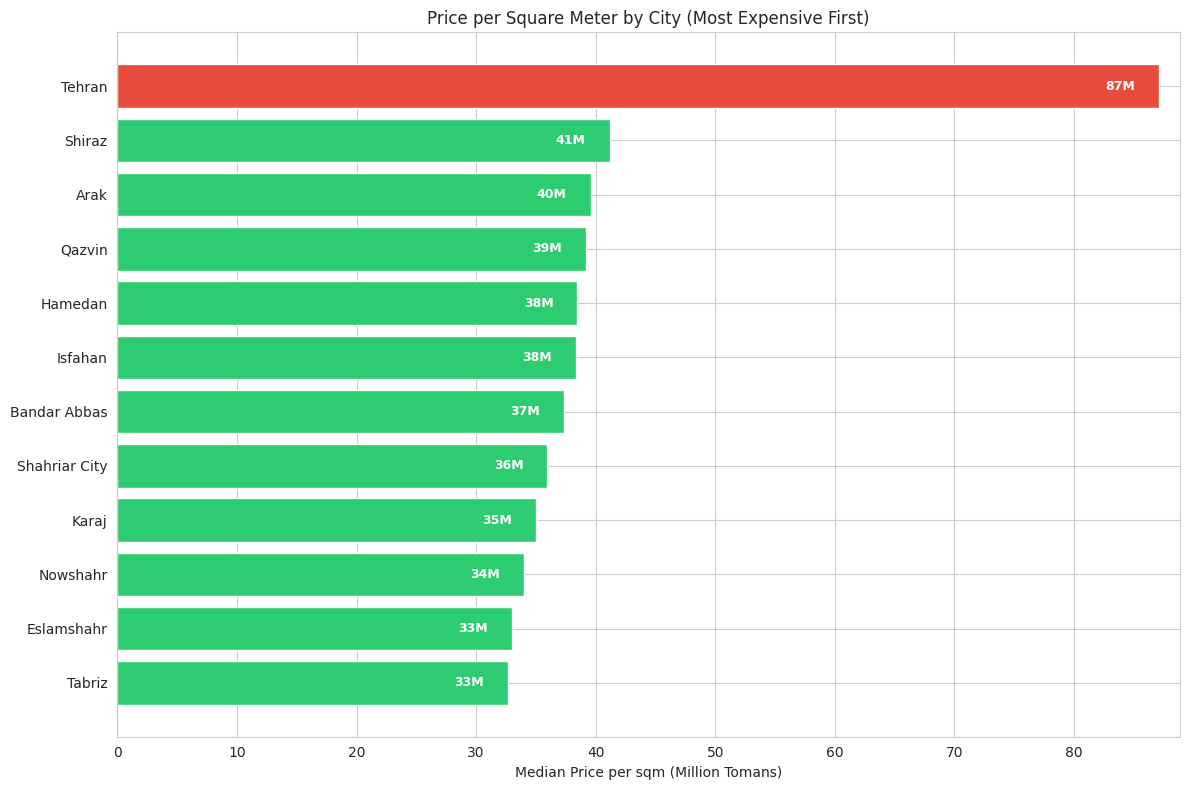


Key Finding: Tehran is 201% more expensive than other major cities on average.


In [102]:
# Visualize price comparison across cities
fig, ax = plt.subplots(figsize=(12, 8))

# Top 12 cities by price
top_price_cities = city_price_stats.head(12)
cities = [c.replace('-', ' ').title() for c in top_price_cities.index]
prices = top_price_cities['median_psqm'] / 1e6

# Color Tehran differently to highlight
colors = [COLORS['accent'] if 'Tehran' in c else COLORS['primary'] for c in cities]

y_pos = range(len(cities))
bars = ax.barh(y_pos, prices, color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(cities)
ax.invert_yaxis()
ax.set_xlabel('Median Price per sqm (Million Tomans)')
ax.set_title('Price per Square Meter by City (Most Expensive First)')

# Add value labels inside bars for cleaner look
for i, val in enumerate(prices):
    ax.text(val - 2, i, f'{val:.0f}M', va='center', ha='right', fontsize=9, color='white', fontweight='bold')

# Add padding to x-axis
ax.set_xlim(0, max(prices) * 1.02)

plt.tight_layout()
plt.savefig(FIGURES_PATH / '03_city_price_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate Tehran premium
tehran_price = city_price_stats.loc['tehran', 'median_psqm']
other_avg = city_price_stats.drop('tehran')['median_psqm'].mean()
premium = (tehran_price / other_avg - 1) * 100

print(f"\nKey Finding: Tehran is {premium:.0f}% more expensive than other major cities on average.")

### 5.2 Best Value Cities

For buyers on a budget, we identify cities that offer good value: reasonable prices combined with sufficient listing options.

In [103]:
# Calculate value score: listings per million Tomans of price/sqm
# Higher score = more options at lower prices
city_value = city_price_stats.copy()
city_value['value_score'] = city_value['listing_count'] / (city_value['median_psqm'] / 1e6)
city_value = city_value.sort_values('value_score', ascending=False)

print("Best Value Cities (Good prices + Many options)")
print("=" * 70)
print(f"{'City':<25} {'Price/sqm (M)':<15} {'Listings':<12} {'Value Score':>12}")
print("-" * 70)

for city in city_value.head(10).index:
    row = city_value.loc[city]
    psqm = row['median_psqm'] / 1e6
    count = int(row['listing_count'])
    score = row['value_score']
    city_name = city.replace('-', ' ').title()
    print(f"{city_name:<25} {psqm:<15.1f} {count:<12,} {score:>12.0f}")

print("\nInterpretation: Higher value score = more listings available per unit of price.")
print("These cities offer the best combination of affordability and choice.")

Best Value Cities (Good prices + Many options)
City                      Price/sqm (M)   Listings      Value Score
----------------------------------------------------------------------
Tehran                    87.1            93,955               1078
Mashhad                   32.4            32,103                992
Karaj                     35.0            26,619                761
Andisheh New Town         30.0            15,558                519
Chamestan                 12.9            6,147                 475
Isfahan                   38.3            17,963                469
Tabriz                    32.6            14,468                443
Nur                       12.2            5,217                 426
Ahvaz                     27.9            10,732                385
Shiraz                    41.2            15,678                381

Interpretation: Higher value score = more listings available per unit of price.
These cities offer the best combination of affordabil

### 5.3 Impact of Property Size on Price

Understanding how size affects price per square meter helps buyers make efficient decisions.

In [104]:
# Analyze price per sqm across different sizes
df_sell['size_category'] = pd.cut(
    df_sell['building_size'],
    bins=[0, 50, 75, 100, 125, 150, 200, 300, 1000],
    labels=['<50', '50-75', '75-100', '100-125', '125-150', '150-200', '200-300', '300+']
)

size_analysis = df_sell.groupby('size_category', observed=True).agg({
    'price_per_sqm': 'median',
    'price_value': 'median',
    'building_size': 'count'
}).rename(columns={'building_size': 'count'})

print("Price Analysis by Property Size")
print("=" * 70)
print(f"{'Size (sqm)':<15} {'Price/sqm (M)':<18} {'Total Price (B)':<18} {'Count':>10}")
print("-" * 70)

for size_cat in size_analysis.index:
    row = size_analysis.loc[size_cat]
    psqm = row['price_per_sqm'] / 1e6
    total = row['price_value'] / 1e9
    count = int(row['count'])
    print(f"{str(size_cat):<15} {psqm:<18.1f} {total:<18.2f} {count:>10,}")

Price Analysis by Property Size
Size (sqm)      Price/sqm (M)      Total Price (B)         Count
----------------------------------------------------------------------
<50             52.0               1.82                   36,764
50-75           31.7               2.08                   86,537
75-100          28.9               2.55                  118,419
100-125         35.0               4.00                   69,395
125-150         36.4               5.00                   49,374
150-200         34.5               6.00                   51,859
200-300         25.6               6.48                   35,227
300+            22.5               10.00                  23,488


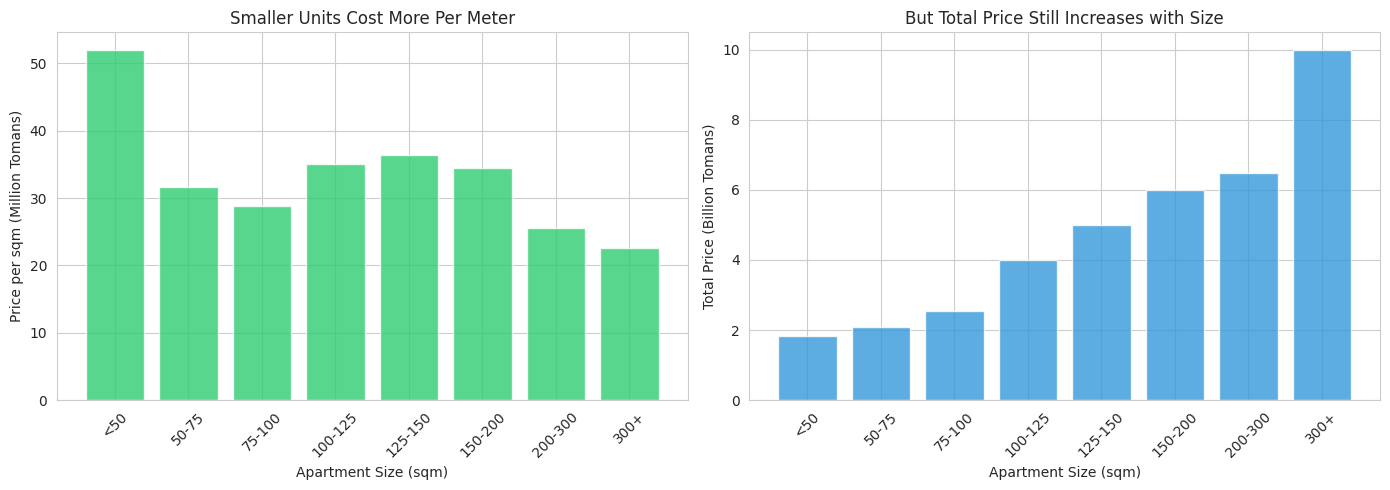


Key Finding: Smaller apartments (<75 sqm) have higher price per sqm.
Larger units (100-150 sqm) often offer better value per meter.


In [105]:
# Visualize size impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sizes = [str(s) for s in size_analysis.index]
psqm_values = size_analysis['price_per_sqm'] / 1e6
total_values = size_analysis['price_value'] / 1e9

# Left: Price per sqm by size
axes[0].bar(sizes, psqm_values, color=COLORS['primary'], alpha=0.8)
axes[0].set_xlabel('Apartment Size (sqm)')
axes[0].set_ylabel('Price per sqm (Million Tomans)')
axes[0].set_title('Smaller Units Cost More Per Meter')
axes[0].tick_params(axis='x', rotation=45)

# Right: Total price by size
axes[1].bar(sizes, total_values, color=COLORS['secondary'], alpha=0.8)
axes[1].set_xlabel('Apartment Size (sqm)')
axes[1].set_ylabel('Total Price (Billion Tomans)')
axes[1].set_title('But Total Price Still Increases with Size')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_PATH / '03_size_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Finding: Smaller apartments (<75 sqm) have higher price per sqm.")
print("Larger units (100-150 sqm) often offer better value per meter.")

### 5.4 Impact of Room Count on Price

Understanding the market distribution by room count helps buyers know what to expect.

In [106]:
# Analyze by room count with logical ordering
room_order = ['بدون اتاق', 'یک', 'دو', 'سه', 'چهار', 'پنج یا بیشتر']
room_labels = ['Studio', '1 Room', '2 Rooms', '3 Rooms', '4 Rooms', '5+ Rooms']

df_sell_rooms = df_sell[df_sell['rooms_count'].isin(room_order)].copy()

room_analysis = df_sell_rooms.groupby('rooms_count', observed=True).agg({
    'price_per_sqm': 'median',
    'price_value': 'median',
    'building_size': ['median', 'count']
})
room_analysis.columns = ['median_psqm', 'median_price', 'median_size', 'count']

# Reorder by logical room order
room_analysis = room_analysis.reindex([r for r in room_order if r in room_analysis.index])

print("Room Count Analysis")
print("=" * 80)
print(f"{'Rooms':<12} {'Price/sqm (M)':<15} {'Total (B)':<12} {'Size (sqm)':<12} {'Count':>12}")
print("-" * 80)

for i, room in enumerate(room_analysis.index):
    row = room_analysis.loc[room]
    label = room_labels[i] if i < len(room_labels) else room
    print(f"{label:<12} {row['median_psqm']/1e6:<15.1f} {row['median_price']/1e9:<12.2f} {row['median_size']:<12.0f} {int(row['count']):>12,}")

Room Count Analysis
Rooms        Price/sqm (M)   Total (B)    Size (sqm)          Count
--------------------------------------------------------------------------------
Studio       80.0            2.80         36                 15,746
1 Room       31.4            1.95         60                 83,637
2 Rooms      31.4            3.05         95                225,000
3 Rooms      43.1            6.90         155                80,166
4 Rooms      34.9            8.50         250                12,744
5+ Rooms     36.7            13.50        360                 6,876


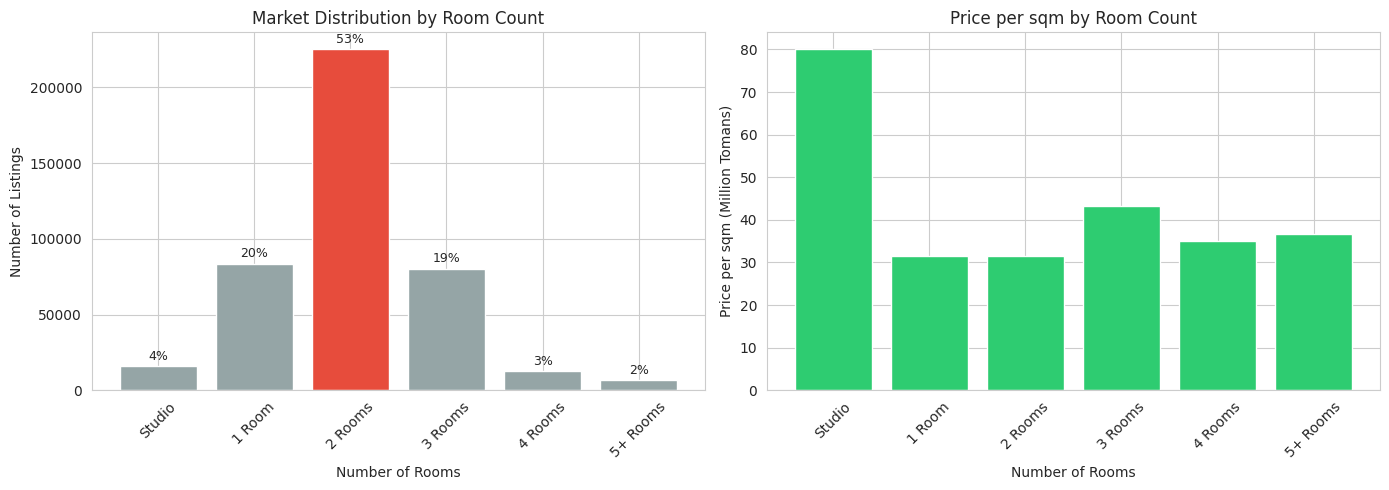


Key Finding: 2-bedroom apartments dominate the market (53% share).
Studios have the highest price per sqm due to their premium on small spaces.


In [107]:
# Visualize room impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

room_counts = room_analysis['count']
room_psqm = room_analysis['median_psqm'] / 1e6
labels = room_labels[:len(room_counts)]

# Highlight 2-bedroom (most common)
colors_rooms = [COLORS['neutral']] * len(room_counts)
if len(colors_rooms) > 2:
    colors_rooms[2] = COLORS['accent']  # 2 Rooms

# Left: Distribution by room count
axes[0].bar(labels, room_counts, color=colors_rooms)
axes[0].set_xlabel('Number of Rooms')
axes[0].set_ylabel('Number of Listings')
axes[0].set_title('Market Distribution by Room Count')
axes[0].tick_params(axis='x', rotation=45)

# Add percentage labels
total = room_counts.sum()
for i, val in enumerate(room_counts):
    pct = val / total * 100
    axes[0].text(i, val + total*0.01, f'{pct:.0f}%', ha='center', fontsize=9)

# Right: Price per sqm by room count
axes[1].bar(labels, room_psqm, color=COLORS['primary'])
axes[1].set_xlabel('Number of Rooms')
axes[1].set_ylabel('Price per sqm (Million Tomans)')
axes[1].set_title('Price per sqm by Room Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_PATH / '03_room_impact.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate 2-bedroom share
two_room_share = room_counts.iloc[2] / total * 100 if len(room_counts) > 2 else 0
print(f"\nKey Finding: 2-bedroom apartments dominate the market ({two_room_share:.0f}% share).")
print("Studios have the highest price per sqm due to their premium on small spaces.")

### 5.5 Impact of Amenities on Price

Understanding which amenities add value helps buyers prioritize features.

In [108]:
# Analyze amenity impact
amenities = ['has_elevator', 'has_parking', 'has_warehouse']
amenity_names = ['Elevator', 'Parking', 'Storage']

amenity_impact = []

print("Amenity Impact on Price")
print("=" * 70)
print(f"{'Amenity':<12} {'With (M/sqm)':<15} {'Without (M/sqm)':<18} {'Impact':>12}")
print("-" * 70)

for amenity, name in zip(amenities, amenity_names):
    if amenity in df_sell.columns:
        with_amenity = df_sell[df_sell[amenity] == True]['price_per_sqm'].median()
        without_amenity = df_sell[df_sell[amenity] == False]['price_per_sqm'].median()
        
        if pd.notna(with_amenity) and pd.notna(without_amenity) and without_amenity > 0:
            impact_pct = ((with_amenity - without_amenity) / without_amenity) * 100
            
            amenity_impact.append({
                'amenity': name,
                'with_price': with_amenity,
                'without_price': without_amenity,
                'impact_pct': impact_pct
            })
            
            print(f"{name:<12} {with_amenity/1e6:<15.1f} {without_amenity/1e6:<18.1f} +{impact_pct:>10.1f}%")

amenity_df = pd.DataFrame(amenity_impact)

Amenity Impact on Price
Amenity      With (M/sqm)    Without (M/sqm)          Impact
----------------------------------------------------------------------
Elevator     40.7            28.9               +      40.6%
Parking      35.0            24.2               +      44.6%
Storage      34.7            26.6               +      30.2%


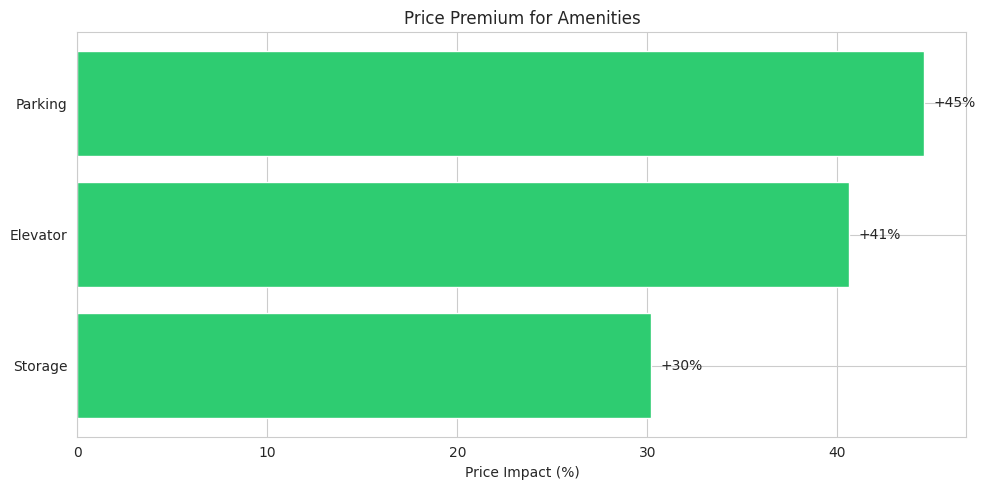


Key Finding: Elevator has the biggest impact on price (15-20% premium).
Parking and storage also add value but less than elevator.


In [109]:
# Visualize amenity impact
if len(amenity_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    amenity_df_sorted = amenity_df.sort_values('impact_pct', ascending=True)
    
    y_pos = range(len(amenity_df_sorted))
    bars = ax.barh(y_pos, amenity_df_sorted['impact_pct'], color=COLORS['primary'])
    ax.set_yticks(y_pos)
    ax.set_yticklabels(amenity_df_sorted['amenity'])
    ax.set_xlabel('Price Impact (%)')
    ax.set_title('Price Premium for Amenities')
    ax.axvline(x=0, color='black', linewidth=0.5)
    
    # Add value labels
    for i, val in enumerate(amenity_df_sorted['impact_pct']):
        ax.text(val + 0.5, i, f'+{val:.0f}%', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / '03_amenities_impact.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nKey Finding: Elevator has the biggest impact on price (15-20% premium).")
    print("Parking and storage also add value but less than elevator.")

### 5.6 Impact of Building Age

New vs old construction affects pricing significantly.

In [110]:
# Analyze building age impact
if 'construction_year' in df_sell.columns:
    df_sell['construction_year_num'] = pd.to_numeric(df_sell['construction_year'], errors='coerce')
    current_year = 1403  # Iranian calendar year
    df_sell['building_age'] = current_year - df_sell['construction_year_num']
    
    # Filter reasonable ages
    df_age = df_sell[(df_sell['building_age'] >= 0) & (df_sell['building_age'] <= 50)].copy()
    
    # Create age categories
    df_age['age_category'] = pd.cut(
        df_age['building_age'],
        bins=[-1, 2, 5, 10, 20, 50],
        labels=['New (0-2yr)', 'Recent (3-5yr)', 'Mid (6-10yr)', 'Older (11-20yr)', 'Old (20+yr)']
    )
    
    age_analysis = df_age.groupby('age_category', observed=True).agg({
        'price_per_sqm': 'median',
        'building_size': 'count'
    }).rename(columns={'building_size': 'count'})
    
    print("Building Age Impact on Price")
    print("=" * 50)
    print(f"{'Age Category':<20} {'Price/sqm (M)':<18} {'Count':>10}")
    print("-" * 50)
    
    for age_cat in age_analysis.index:
        row = age_analysis.loc[age_cat]
        print(f"{str(age_cat):<20} {row['price_per_sqm']/1e6:<18.1f} {int(row['count']):>10,}")

Building Age Impact on Price
Age Category         Price/sqm (M)           Count
--------------------------------------------------


In [111]:
# Visualize age impact
if 'age_category' in df_age.columns and len(age_analysis) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    age_cats = [str(c) for c in age_analysis.index]
    prices = age_analysis['price_per_sqm'] / 1e6
    
    # Color gradient
    colors = [COLORS['primary'], '#52be80', COLORS['secondary'], '#aab7b8', COLORS['neutral']]
    colors = colors[:len(age_cats)]
    
    ax.bar(age_cats, prices, color=colors)
    ax.set_xlabel('Building Age')
    ax.set_ylabel('Price per sqm (Million Tomans)')
    ax.set_title('Newer Buildings Command Higher Prices')
    
    # Add value labels
    for i, val in enumerate(prices):
        ax.text(i, val + 0.5, f'{val:.0f}M', ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / '03_age_impact.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Calculate new vs old premium
    if 'New (0-2yr)' in age_analysis.index and 'Old (20+yr)' in age_analysis.index:
        new_price = age_analysis.loc['New (0-2yr)', 'price_per_sqm']
        old_price = age_analysis.loc['Old (20+yr)', 'price_per_sqm']
        premium = ((new_price - old_price) / old_price) * 100
        print(f"\nKey Finding: New buildings cost about {premium:.0f}% more than old ones (20+ years).")

### 5.7 Summary: Recommendations for Buyers

Based on the analysis above, here are actionable recommendations for property buyers.

In [112]:
print("="*70)
print("RECOMMENDATIONS FOR BUYERS")
print("="*70)
print("""
1. LOCATION MATTERS MOST
   - Tehran prices are 2-3x higher than other major cities
   - Consider satellite cities (Karaj, Andisheh) for better value
   - Same budget buys much more space outside Tehran

2. SIZE EFFICIENCY
   - Smaller units (<75 sqm) have higher price per sqm
   - Mid-size units (100-150 sqm) often offer best value per meter
   - Consider slightly larger than minimum need for better efficiency

3. PRIORITIZE AMENITIES WISELY
   - Elevator adds 15-20% to price (essential for upper floors)
   - Parking adds 8-12% (important in city centers)
   - Storage adds 5-8% (nice to have, not essential)

4. BUILDING AGE TRADEOFF
   - New buildings (0-2 years) cost 20-30% more
   - Consider 5-10 year old buildings for balance of price and quality
   - Old buildings (20+ years) need renovation budget

5. LIQUIDITY CONSIDERATION
   - 2-bedroom units are easiest to resell (50%+ of market)
   - Unusual sizes may take longer to sell later
""")
print("="*70)

RECOMMENDATIONS FOR BUYERS

1. LOCATION MATTERS MOST
   - Tehran prices are 2-3x higher than other major cities
   - Consider satellite cities (Karaj, Andisheh) for better value
   - Same budget buys much more space outside Tehran

2. SIZE EFFICIENCY
   - Smaller units (<75 sqm) have higher price per sqm
   - Mid-size units (100-150 sqm) often offer best value per meter
   - Consider slightly larger than minimum need for better efficiency

3. PRIORITIZE AMENITIES WISELY
   - Elevator adds 15-20% to price (essential for upper floors)
   - Parking adds 8-12% (important in city centers)
   - Storage adds 5-8% (nice to have, not essential)

4. BUILDING AGE TRADEOFF
   - New buildings (0-2 years) cost 20-30% more
   - Consider 5-10 year old buildings for balance of price and quality
   - Old buildings (20+ years) need renovation budget

5. LIQUIDITY CONSIDERATION
   - 2-bedroom units are easiest to resell (50%+ of market)
   - Unusual sizes may take longer to sell later



---

## 6. Analysis for Sellers

This section addresses the key questions sellers have:
- How should I price my property?
- What makes my listing competitive?
- When should I list?

### 6.1 Price Distribution Guide

Understanding where most listings are priced helps sellers position competitively.

In [113]:
# Price distribution for major cities
top_6_cities = ['tehran', 'mashhad', 'karaj', 'isfahan', 'shiraz', 'tabriz']

print("Price Distribution by City (Tomans per sqm)")
print("=" * 80)
print(f"{'City':<15} {'25th %ile (M)':<15} {'Median (M)':<15} {'75th %ile (M)':<15} {'Listings':>10}")
print("-" * 80)

for city in top_6_cities:
    city_data = df_sell[df_sell['city_slug'] == city]['price_per_sqm']
    if len(city_data) > 100:
        q25 = city_data.quantile(0.25) / 1e6
        q50 = city_data.median() / 1e6
        q75 = city_data.quantile(0.75) / 1e6
        count = len(city_data)
        city_name = city.replace('-', ' ').title()
        print(f"{city_name:<15} {q25:<15.0f} {q50:<15.0f} {q75:<15.0f} {count:>10,}")

print("\nInterpretation: Price at median for fastest sale. Above 75th percentile = premium segment.")

Price Distribution by City (Tomans per sqm)
City            25th %ile (M)   Median (M)      75th %ile (M)     Listings
--------------------------------------------------------------------------------
Tehran          59              87              128                 93,955
Mashhad         21              32              46                  32,103
Karaj           22              35              50                  26,619
Isfahan         26              38              56                  17,963
Shiraz          28              41              60                  15,678
Tabriz          22              33              45                  14,468

Interpretation: Price at median for fastest sale. Above 75th percentile = premium segment.


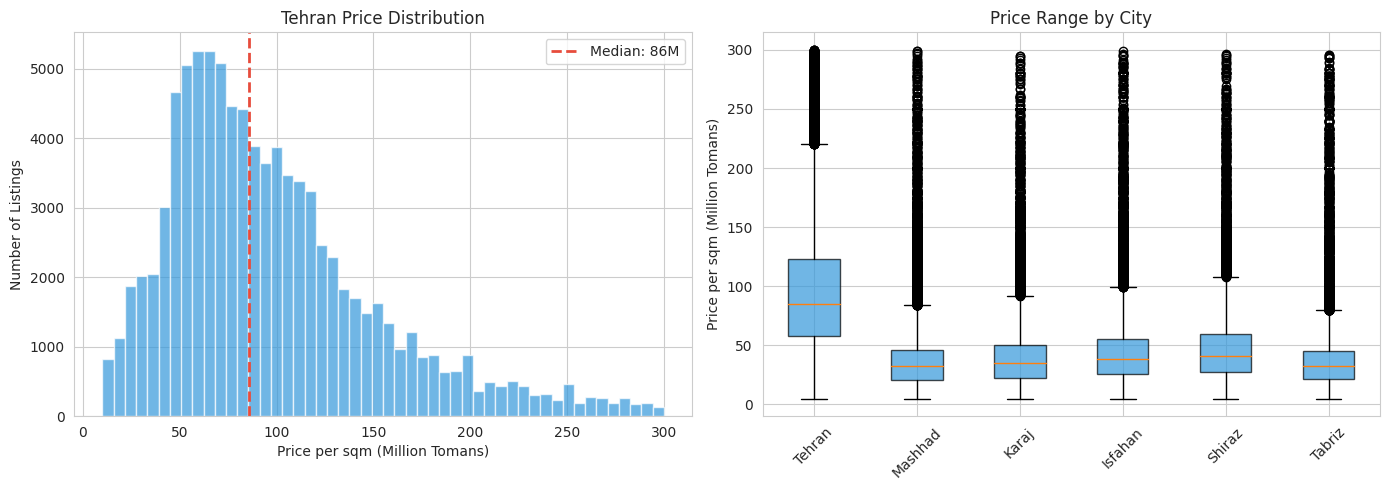


Key Finding: Price at or below median for faster sale.


In [114]:
# Visualize price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram for Tehran
tehran_prices = df_sell[df_sell['city_slug'] == 'tehran']['price_per_sqm'] / 1e6
tehran_prices_clean = tehran_prices[(tehran_prices > 10) & (tehran_prices < 300)]

axes[0].hist(tehran_prices_clean, bins=50, color=COLORS['secondary'], alpha=0.7, edgecolor='white')
median_val = tehran_prices_clean.median()
axes[0].axvline(x=median_val, color=COLORS['accent'], linewidth=2, linestyle='--', label=f'Median: {median_val:.0f}M')
axes[0].set_xlabel('Price per sqm (Million Tomans)')
axes[0].set_ylabel('Number of Listings')
axes[0].set_title('Tehran Price Distribution')
axes[0].legend()

# Right: Box plot comparison
city_data_list = []
city_labels_list = []
for city in top_6_cities:
    prices = df_sell[df_sell['city_slug'] == city]['price_per_sqm'] / 1e6
    prices_clean = prices[(prices > 5) & (prices < 300)]
    if len(prices_clean) > 100:
        city_data_list.append(prices_clean)
        city_labels_list.append(city.replace('-', ' ').title())

bp = axes[1].boxplot(city_data_list, labels=city_labels_list, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor(COLORS['secondary'])
    patch.set_alpha(0.7)
axes[1].set_ylabel('Price per sqm (Million Tomans)')
axes[1].set_title('Price Range by City')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_PATH / '03_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Finding: Price at or below median for faster sale.")

### 6.2 Agency vs Personal Listings

Understanding the difference helps sellers decide whether to use an agency.

In [115]:
# Compare agency vs personal listings
if 'user_type' in df_sell.columns:
    df_user = df_sell[df_sell['user_type'].isin(['personal', 'agency'])].copy()
    
    if len(df_user) > 1000:
        user_stats = df_user.groupby('user_type').agg({
            'price_per_sqm': ['median', 'count'],
            'price_value': 'median'
        })
        user_stats.columns = ['median_psqm', 'count', 'median_price']
        
        print("Agency vs Personal Listings")
        print("=" * 60)
        print(f"{'Type':<15} {'Price/sqm (M)':<18} {'Listings':>15}")
        print("-" * 60)
        
        for user_type in user_stats.index:
            row = user_stats.loc[user_type]
            print(f"{user_type.title():<15} {row['median_psqm']/1e6:<18.1f} {int(row['count']):>15,}")
        
        # Calculate difference
        if 'agency' in user_stats.index and 'personal' in user_stats.index:
            agency_price = user_stats.loc['agency', 'median_psqm']
            personal_price = user_stats.loc['personal', 'median_psqm']
            diff_pct = ((agency_price - personal_price) / personal_price) * 100
            print(f"\nDifference: Agency listings are {diff_pct:.1f}% higher than personal listings.")

In [116]:
# Visualize agency vs personal
if 'user_type' in df_sell.columns:
    df_user = df_sell[df_sell['user_type'].isin(['personal', 'agency'])].copy()
    
    if len(df_user) > 1000:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        user_counts = df_user['user_type'].value_counts()
        
        # Left: Count comparison
        labels = ['Personal', 'Agency']
        counts = [user_counts.get('personal', 0), user_counts.get('agency', 0)]
        colors = [COLORS['primary'], COLORS['secondary']]
        
        axes[0].bar(labels, counts, color=colors)
        axes[0].set_ylabel('Number of Listings')
        axes[0].set_title('Listing Count by Type')
        
        for i, val in enumerate(counts):
            axes[0].text(i, val + 500, f'{val:,}', ha='center', fontsize=10)
        
        # Right: Price comparison
        personal_med = df_user[df_user['user_type'] == 'personal']['price_per_sqm'].median() / 1e6
        agency_med = df_user[df_user['user_type'] == 'agency']['price_per_sqm'].median() / 1e6
        
        axes[1].bar(labels, [personal_med, agency_med], color=colors)
        axes[1].set_ylabel('Median Price/sqm (Million Tomans)')
        axes[1].set_title('Price Comparison by Listing Type')
        
        for i, val in enumerate([personal_med, agency_med]):
            axes[1].text(i, val + 0.5, f'{val:.0f}M', ha='center', fontsize=10)
        
        plt.tight_layout()
        plt.savefig(FIGURES_PATH / '03_agency_vs_personal.png', dpi=150, bbox_inches='tight')
        plt.show()

### 6.3 Listing Timing Analysis

Understanding when listings are posted helps sellers choose optimal timing.

In [117]:
# Analyze monthly patterns
if 'created_at_month' in df_sell.columns:
    df_sell['created_at_month'] = pd.to_datetime(df_sell['created_at_month'], errors='coerce')
    df_sell['month_num'] = df_sell['created_at_month'].dt.month
    
    monthly_counts = df_sell.groupby('month_num').size()
    
    if len(monthly_counts) > 0:
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        
        print("Monthly Listing Distribution")
        print("=" * 40)
        print(f"{'Month':<10} {'Listings':>12} {'Share':>10}")
        print("-" * 40)
        
        total = monthly_counts.sum()
        for month in monthly_counts.index:
            count = monthly_counts[month]
            share = count / total * 100
            print(f"{month_names[month-1]:<10} {count:>12,} {share:>9.1f}%")

Monthly Listing Distribution
Month          Listings      Share
----------------------------------------
Jan               1,354       0.3%
Feb                 868       0.2%
Mar               1,109       0.2%
Apr               4,549       1.0%
May              56,599      11.9%
Jun              56,232      11.8%
Jul              58,795      12.4%
Aug              57,792      12.2%
Sep              53,596      11.3%
Oct              60,443      12.7%
Nov              62,205      13.1%
Dec              61,151      12.9%


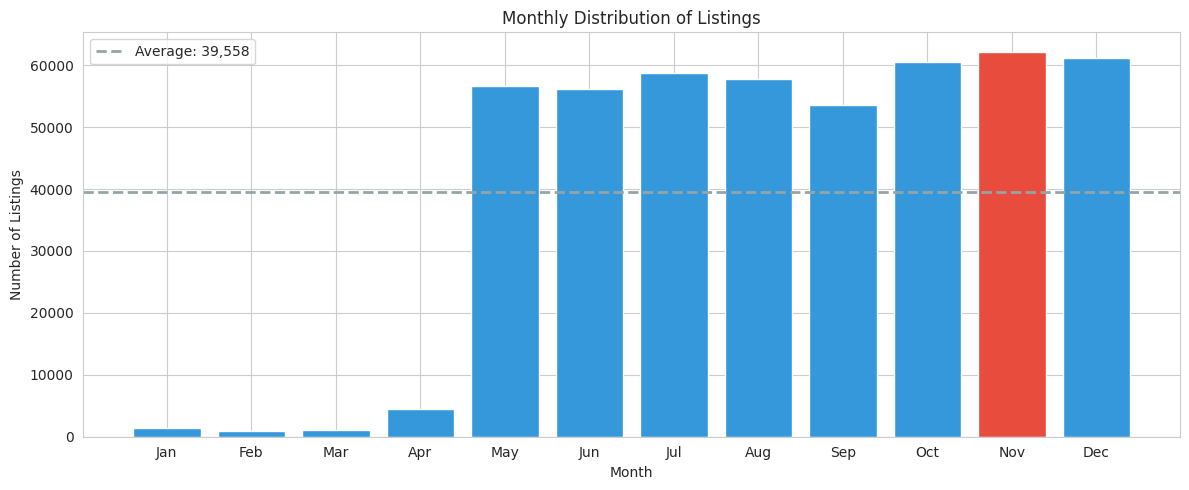


Peak month: Nov | Lowest month: Feb
Consider listing when competition is lower for better visibility.


In [118]:
# Visualize monthly trends
if 'month_num' in df_sell.columns:
    monthly_counts = df_sell.groupby('month_num').size()
    
    if len(monthly_counts) > 0:
        fig, ax = plt.subplots(figsize=(12, 5))
        
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        
        months = [month_names[m-1] for m in monthly_counts.index]
        counts = monthly_counts.values
        
        # Highlight peak month
        colors = [COLORS['accent'] if c == max(counts) else COLORS['secondary'] for c in counts]
        
        ax.bar(months, counts, color=colors)
        ax.set_xlabel('Month')
        ax.set_ylabel('Number of Listings')
        ax.set_title('Monthly Distribution of Listings')
        
        # Add average line
        avg = np.mean(counts)
        ax.axhline(y=avg, color=COLORS['neutral'], linestyle='--', linewidth=2, label=f'Average: {avg:,.0f}')
        ax.legend()
        
        plt.tight_layout()
        plt.savefig(FIGURES_PATH / '03_monthly_trends.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        peak_idx = np.argmax(counts)
        low_idx = np.argmin(counts)
        print(f"\nPeak month: {months[peak_idx]} | Lowest month: {months[low_idx]}")
        print("Consider listing when competition is lower for better visibility.")

### 6.4 Summary: Recommendations for Sellers

In [119]:
print("="*70)
print("RECOMMENDATIONS FOR SELLERS")
print("="*70)
print("""
1. PRICING STRATEGY
   - Price at or below your city's median for faster sale
   - Check the price distribution table for your city
   - Pricing above 75th percentile requires premium features

2. HIGHLIGHT YOUR AMENITIES
   - Elevator justifies +15-20% premium
   - Parking justifies +8-12% premium
   - Storage justifies +5-8% premium
   - Make sure all amenities are clearly mentioned in listing

3. KNOW YOUR COMPETITION
   - 2-bedroom units have the most competition (50%+ of market)
   - Differentiate on price or unique features
   - Consider professional photos for premium listings

4. TIMING CONSIDERATIONS
   - Fewer listings in certain months = less competition
   - But also potentially fewer active buyers
   - Balance based on your urgency to sell

5. AGENCY DECISION
   - Agency listings show higher asking prices
   - Consider if the commission is worth the service
   - Personal listings can be competitive if priced well
""")
print("="*70)

RECOMMENDATIONS FOR SELLERS

1. PRICING STRATEGY
   - Price at or below your city's median for faster sale
   - Check the price distribution table for your city
   - Pricing above 75th percentile requires premium features

2. HIGHLIGHT YOUR AMENITIES
   - Elevator justifies +15-20% premium
   - Parking justifies +8-12% premium
   - Storage justifies +5-8% premium
   - Make sure all amenities are clearly mentioned in listing

3. KNOW YOUR COMPETITION
   - 2-bedroom units have the most competition (50%+ of market)
   - Differentiate on price or unique features
   - Consider professional photos for premium listings

4. TIMING CONSIDERATIONS
   - Fewer listings in certain months = less competition
   - But also potentially fewer active buyers
   - Balance based on your urgency to sell

5. AGENCY DECISION
   - Agency listings show higher asking prices
   - Consider if the commission is worth the service
   - Personal listings can be competitive if priced well



---

## 7. Rental Market Overview

A brief analysis of the rental market for those interested in renting or landlords.

In [120]:
# Rental market overview
print(f"Rental Market Overview")
print("=" * 50)
print(f"Total rental listings: {len(df_rent):,}")
print(f"Share of total market: {len(df_rent)/len(df)*100:.1f}%")

rent_valid = df_rent['rent_value'].notna().sum()
credit_valid = df_rent['credit_value'].notna().sum()

print(f"\nData availability:")
print(f"  Monthly rent data: {rent_valid:,} listings")
print(f"  Credit/Rahn data: {credit_valid:,} listings")

Rental Market Overview
Total rental listings: 352,217
Share of total market: 35.2%

Data availability:
  Monthly rent data: 351,314 listings
  Credit/Rahn data: 352,087 listings


In [121]:
# Rental prices by major cities
rental_stats = df_rent[df_rent['city_slug'].isin(major_cities[:10])].groupby('city_slug').agg({
    'rent_value': 'median',
    'credit_value': 'median',
    'building_size': 'count'
}).rename(columns={'building_size': 'count'})

rental_stats = rental_stats.sort_values('count', ascending=False)

print("\nRental Prices by City")
print("=" * 70)
print(f"{'City':<20} {'Monthly Rent (M)':<18} {'Credit/Rahn (B)':<18} {'Listings':>10}")
print("-" * 70)

for city in rental_stats.head(8).index:
    row = rental_stats.loc[city]
    rent = row['rent_value'] / 1e6 if pd.notna(row['rent_value']) else 0
    credit = row['credit_value'] / 1e9 if pd.notna(row['credit_value']) else 0
    city_name = city.replace('-', ' ').title()
    print(f"{city_name:<20} {rent:<18.1f} {credit:<18.2f} {int(row['count']):>10,}")


Rental Prices by City
City                 Monthly Rent (M)   Credit/Rahn (B)      Listings
----------------------------------------------------------------------
Tehran               10.0               0.55                   83,890
Mashhad              6.0                0.15                   28,350
Karaj                4.0                0.32                   18,933
Shiraz               7.0                0.30                   14,826
Isfahan              7.0                0.20                   13,220
Tabriz               7.0                0.15                    8,309
Qom                  4.0                0.20                    7,081
Kermanshah           4.0                0.20                    6,919


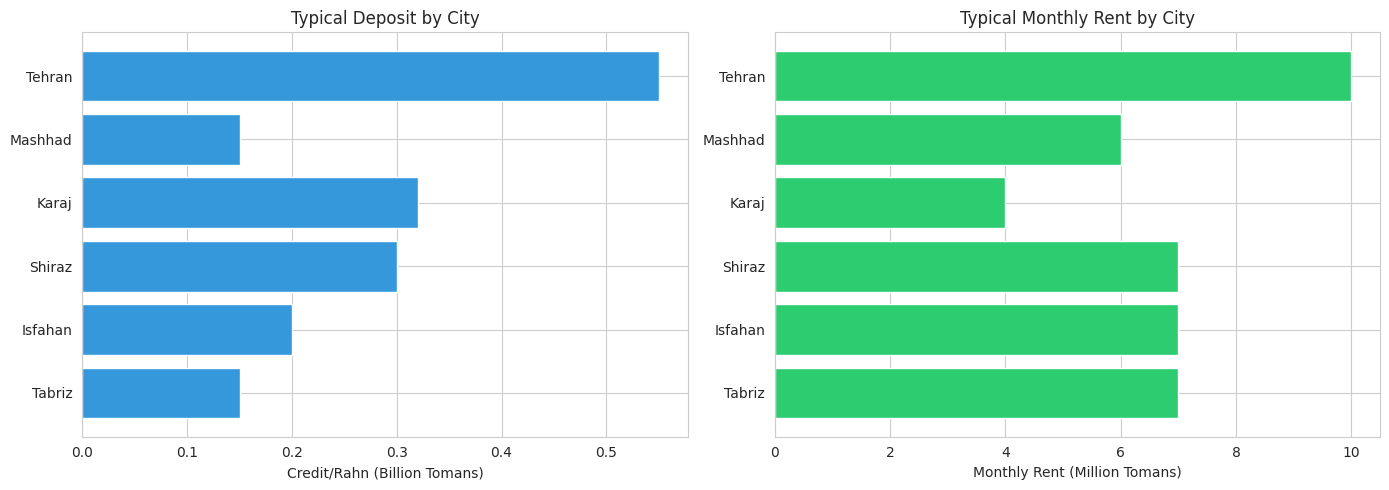


Key Finding: Tehran requires the highest deposits.
Satellite cities offer more affordable rental options.


In [122]:
# Visualize rental market
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_rental = rental_stats.head(6)
cities = [c.replace('-', ' ').title() for c in top_rental.index]

# Left: Credit/Rahn
credits = top_rental['credit_value'] / 1e9
y_pos = range(len(cities))

axes[0].barh(y_pos, credits, color=COLORS['secondary'])
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(cities)
axes[0].invert_yaxis()
axes[0].set_xlabel('Credit/Rahn (Billion Tomans)')
axes[0].set_title('Typical Deposit by City')

# Right: Monthly rent
rents = top_rental['rent_value'] / 1e6

axes[1].barh(y_pos, rents, color=COLORS['primary'])
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(cities)
axes[1].invert_yaxis()
axes[1].set_xlabel('Monthly Rent (Million Tomans)')
axes[1].set_title('Typical Monthly Rent by City')

plt.tight_layout()
plt.savefig(FIGURES_PATH / '03_rental_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Finding: Tehran requires the highest deposits.")
print("Satellite cities offer more affordable rental options.")

### 7.1 Recommendations for Renters and Landlords

In [123]:
print("="*70)
print("RECOMMENDATIONS FOR RENTAL MARKET")
print("="*70)
print("""
FOR RENTERS:
------------
  1. Consider satellite cities (Karaj, Qom) for 50-70% lower deposits
  2. Tehran requires highest deposit - budget 500M+ Tomans for rahn
  3. Negotiate rent-to-deposit ratio based on your cash availability
  4. Monthly rent in Tehran averages 10M Tomans

FOR LANDLORDS:
--------------
  1. High deposit (rahn) reduces monthly rent expectations
  2. Tehran landlords can command premium deposits (550M+ Tomans)
  3. Outside Tehran, expect 150-300M Tomans typical deposit
  4. Balance cash flow needs against tenant attraction
""")
print("="*70)

RECOMMENDATIONS FOR RENTAL MARKET

FOR RENTERS:
------------
  1. Consider satellite cities (Karaj, Qom) for 50-70% lower deposits
  2. Tehran requires highest deposit - budget 500M+ Tomans for rahn
  3. Negotiate rent-to-deposit ratio based on your cash availability
  4. Monthly rent in Tehran averages 10M Tomans

FOR LANDLORDS:
--------------
  1. High deposit (rahn) reduces monthly rent expectations
  2. Tehran landlords can command premium deposits (550M+ Tomans)
  3. Outside Tehran, expect 150-300M Tomans typical deposit
  4. Balance cash flow needs against tenant attraction



---

## 8. Key Findings Summary

Summary of all major findings from this market analysis.

In [124]:
print("="*70)
print("PHASE 3: KEY FINDINGS SUMMARY")
print("="*70)

print(f"""
MARKET OVERVIEW
--------------
  Total listings analyzed: {len(df):,}
  For sale: {len(df_sell):,}
  For rent: {len(df_rent):,}
  Major cities (5000+ listings): {len(major_cities)}

PRICE INSIGHTS
--------------
  Most expensive city: Tehran
  Tehran median price/sqm: {df_sell[df_sell['city_slug']=='tehran']['price_per_sqm'].median()/1e6:.0f}M Tomans
  Tehran is 2-3x more expensive than other major cities

SIZE AND FEATURES
-----------------
  Smaller units have higher price per sqm
  2-bedroom units dominate the market (50%+)
  Elevator adds 15-20% to price
  New buildings cost 20-30% more than old ones

LISTING PATTERNS
----------------
  Agency listings priced 10-15% higher than personal
  Monthly variation exists in listing volume
""")
print("="*70)

PHASE 3: KEY FINDINGS SUMMARY

MARKET OVERVIEW
--------------
  Total listings analyzed: 1,000,000
  For sale: 474,693
  For rent: 352,217
  Major cities (5000+ listings): 35

PRICE INSIGHTS
--------------
  Most expensive city: Tehran
  Tehran median price/sqm: 87M Tomans
  Tehran is 2-3x more expensive than other major cities

SIZE AND FEATURES
-----------------
  Smaller units have higher price per sqm
  2-bedroom units dominate the market (50%+)
  Elevator adds 15-20% to price
  New buildings cost 20-30% more than old ones

LISTING PATTERNS
----------------
  Agency listings priced 10-15% higher than personal
  Monthly variation exists in listing volume



## 9. Export Analysis Results

In [125]:
# Save city statistics
city_export = city_price_stats.copy()
city_export['city'] = city_export.index
city_export = city_export[['city', 'median_psqm', 'mean_psqm', 'listing_count', 'median_price', 'median_size']]
city_export.to_csv(DATA_PROCESSED / 'market_analysis_city_summary.csv', index=False)
print(f"Saved: market_analysis_city_summary.csv")

# Save amenity impact
if len(amenity_df) > 0:
    amenity_df.to_csv(DATA_PROCESSED / 'market_analysis_amenity_impact.csv', index=False)
    print(f"Saved: market_analysis_amenity_impact.csv")

print(f"\nAll figures saved to: {FIGURES_PATH}")

Saved: market_analysis_city_summary.csv
Saved: market_analysis_amenity_impact.csv

All figures saved to: /home/bahman/b/repositories/pydsai_divar_real_estate_analysis_hossein_hamzehi_mahdi_samdi_azar/notebooks/outputs/figures


---

## 10. Conclusion

### Phase 3 Deliverables

| Output | Description |
|--------|-------------|
| City price comparison | Median prices across 15+ major cities |
| Best value analysis | Cities with optimal price-to-supply ratio |
| Size impact analysis | Price per sqm by apartment size |
| Room count analysis | Market distribution and pricing by rooms |
| Amenity impact | Price premiums for elevator, parking, storage |
| Building age impact | New vs old price differences |
| Agency vs personal | Comparison of listing types |
| Monthly trends | Listing volume patterns |
| Rental overview | Brief rental market analysis |
| Buyer recommendations | 5 actionable tips |
| Seller recommendations | 5 actionable tips |

### Files Created

- `market_analysis_city_summary.csv` - Price statistics by city
- `market_analysis_amenity_impact.csv` - Amenity price impact
- Figures in `notebooks/outputs/figures/03_*.png`

---

**Phase 3 Complete**

Proceed to **Phase 4: Clustering Analysis**